# Olist E-commerce Analysis

This notebook loads the provided datasets, merges the core tables, and includes reusable Python programs for cleaning, exploration, and basic business analysis.

In [6]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')

DATA_DIR = Path(r'd:\Data Analytics 1')

def load_csv(name: str) -> pd.DataFrame:
    path = DATA_DIR / name
    return pd.read_csv(path)

customers = load_csv('olist_customers_dataset.csv')
orders = load_csv('olist_orders_dataset.csv')
items = load_csv('olist_order_items_dataset.csv')
payments = load_csv('olist_order_payments_dataset.csv')
reviews = load_csv('olist_order_reviews_dataset.csv')
products = load_csv('olist_products_dataset.csv')
sellers = load_csv('olist_sellers_dataset.csv')
geolocation = load_csv('olist_geolocation_dataset.csv')
category_map = load_csv('product_category_name_translation.csv')

for name, df in {
    'customers': customers,
    'orders': orders,
    'items': items,
    'payments': payments,
    'reviews': reviews,
    'products': products,
    'sellers': sellers,
    'geolocation': geolocation,
    'category_map': category_map,
}.items():
    print(f'{name}: {df.shape}')

customers: (99441, 5)
orders: (99441, 8)
items: (112650, 7)
payments: (103886, 5)
reviews: (99224, 7)
products: (32951, 9)
sellers: (3095, 4)
geolocation: (1000163, 5)
category_map: (71, 2)


In [7]:
# Convert timestamp columns and add helper fields
for column in ['order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']:
    orders[column] = pd.to_datetime(orders[column], errors='coerce')

orders['delivery_days'] = (orders['order_delivered_customer_date'] - orders['order_purchase_timestamp']).dt.days
orders['estimated_delivery_days'] = (orders['order_estimated_delivery_date'] - orders['order_purchase_timestamp']).dt.days
orders['is_late'] = orders['order_delivered_customer_date'] > orders['order_estimated_delivery_date']

# Build a category translation table for analysis
products = products.merge(
    category_map,
    how='left',
    on='product_category_name'
)

# Core merged table at item level
analysis = (
    items
    .merge(orders, on='order_id', how='left')
    .merge(customers, on='customer_id', how='left')
    .merge(products, on='product_id', how='left')
    .merge(sellers, on='seller_id', how='left')
    .merge(payments.groupby('order_id', as_index=False)['payment_value'].sum(), on='order_id', how='left')
    .merge(reviews[['order_id', 'review_score']], on='order_id', how='left')
)

analysis.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_days,estimated_delivery_days,is_late,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english,seller_zip_code_prefix,seller_city,seller_state,payment_value,review_score
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,3ce436f183e68e07877b285a838db11a,delivered,2017-09-13 08:59:02,2017-09-13 09:45:35,2017-09-19 18:34:16,2017-09-20 23:43:48,2017-09-29,7.0,15,False,871766c5855e863f6eccc05f988b23cb,28013,campos dos goytacazes,RJ,cool_stuff,58.0,598.0,4.0,650.0,28.0,9.0,14.0,cool_stuff,27277,volta redonda,SP,72.19,5.0
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,f6dd3ec061db4e3987629fe6b26e5cce,delivered,2017-04-26 10:53:06,2017-04-26 11:05:13,2017-05-04 14:35:00,2017-05-12 16:04:24,2017-05-15,16.0,18,False,eb28e67c4c0b83846050ddfb8a35d051,15775,santa fe do sul,SP,pet_shop,56.0,239.0,2.0,30000.0,50.0,30.0,40.0,pet_shop,3471,sao paulo,SP,259.83,4.0
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,6489ae5e4333f3693df5ad4372dab6d3,delivered,2018-01-14 14:33:31,2018-01-14 14:48:30,2018-01-16 12:36:48,2018-01-22 13:19:16,2018-02-05,7.0,21,False,3818d81c6709e39d06b2738a8d3a2474,35661,para de minas,MG,moveis_decoracao,59.0,695.0,2.0,3050.0,33.0,13.0,33.0,furniture_decor,37564,borda da mata,MG,216.87,5.0
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,d4eb9395c8c0431ee92fce09860c5a06,delivered,2018-08-08 10:00:35,2018-08-08 10:10:18,2018-08-10 13:28:00,2018-08-14 13:32:39,2018-08-20,6.0,11,False,af861d436cfc08b2c2ddefd0ba074622,12952,atibaia,SP,perfumaria,42.0,480.0,1.0,200.0,16.0,10.0,15.0,perfumery,14403,franca,SP,25.78,4.0
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,58dbd0b2d70206bf40e62cd34e84d795,delivered,2017-02-04 13:57:51,2017-02-04 14:10:13,2017-02-16 09:46:09,2017-03-01 16:42:31,2017-03-17,25.0,40,False,64b576fb70d441e8f1b2d7d446e483c5,13226,varzea paulista,SP,ferramentas_jardim,59.0,409.0,1.0,3750.0,35.0,40.0,30.0,garden_tools,87900,loanda,PR,218.04,5.0


In [8]:
# Basic quality checks
summary = pd.DataFrame({
    'rows': [len(df) for df in [customers, orders, items, payments, reviews, products, sellers, geolocation, category_map]],
    'missing_values': [df.isna().sum().sum() for df in [customers, orders, items, payments, reviews, products, sellers, geolocation, category_map]],
}, index=['customers', 'orders', 'items', 'payments', 'reviews', 'products', 'sellers', 'geolocation', 'category_map'])

summary

,rows,missing_values
customers,99441,0
orders,99441,7873
items,112650,0
payments,103886,0
reviews,99224,145903
products,32951,3071
sellers,3095,0
geolocation,1000163,0
category_map,71,0


## Dataset Information

The cells below provide a complete reusable analysis workflow for the Olist dataset.

In [9]:
datasets = {
    'Customers': customers,
    'Orders': orders,
    'Order Items': items,
    'Payments': payments,
    'Reviews': reviews,
    'Products': products,
    'Sellers': sellers,
    'Geolocation': geolocation,
}

for name, df in datasets.items():
    print('=' * 60)
    print(name)
    print(df.info())

Customers
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB
None
Orders
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 11 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  object        
 1   customer_id                    99441 non-null  object        
 2   order_status                   99441 non-null  object       

In [10]:
## Missing Values
for name, df in datasets.items():
    print('\n', name)
    print(df.isnull().sum())


 Customers
customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

 Orders
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
delivery_days                    2965
estimated_delivery_days             0
is_late                             0
dtype: int64

 Order Items
order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64

 Payments
order_id                0
payment_sequential      0
payment_type            0
payment_installments    0
payment_value           0
dtype: int64

 Reviews
review_id          

In [11]:
## Duplicate Records
for name, df in datasets.items():
    print(name)
    print('Duplicate Rows:', df.duplicated().sum())

Customers
Duplicate Rows: 0
Orders
Duplicate Rows: 0
Order Items
Duplicate Rows: 0
Payments
Duplicate Rows: 0
Reviews
Duplicate Rows: 0
Products
Duplicate Rows: 0
Sellers
Duplicate Rows: 0
Geolocation
Duplicate Rows: 261831


In [12]:
## Statistical Summary
for name, df in datasets.items():
    print(name)
    print(df.describe(include='all'))

Customers
                             customer_id                customer_unique_id  \
count                              99441                             99441   
unique                             99441                             96096   
top     06b8999e2fba1a1fbc88172c00ba8bc7  8d50f5eadf50201ccdcedfb9e2ac8455   
freq                                   1                                17   
mean                                 NaN                               NaN   
std                                  NaN                               NaN   
min                                  NaN                               NaN   
25%                                  NaN                               NaN   
50%                                  NaN                               NaN   
75%                                  NaN                               NaN   
max                                  NaN                               NaN   

        customer_zip_code_prefix customer_city custom

In [13]:
## Data Cleaning
customers.drop_duplicates(inplace=True)
orders.drop_duplicates(inplace=True)
products.drop_duplicates(inplace=True)
payments.drop_duplicates(inplace=True)
reviews.drop_duplicates(inplace=True)
items.drop_duplicates(inplace=True)

products['product_category_name'].fillna('Unknown', inplace=True)
products['product_name_lenght'].fillna(products['product_name_lenght'].median(), inplace=True)
reviews['review_comment_message'].fillna('No Review', inplace=True)

orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'], errors='coerce')
orders['order_delivered_customer_date'] = pd.to_datetime(orders['order_delivered_customer_date'], errors='coerce')
orders['order_estimated_delivery_date'] = pd.to_datetime(orders['order_estimated_delivery_date'], errors='coerce')

C:\Users\ASUS\AppData\Local\Temp\ipykernel_10788\1342414530.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  products['product_category_name'].fillna('Unknown', inplace=True)
C:\Users\ASUS\AppData\Local\Temp\ipykernel_10788\1342414530.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as 

In [14]:
## Feature Engineering
orders['delivery_days'] = (orders['order_delivered_customer_date'] - orders['order_purchase_timestamp']).dt.days
orders['delivery_delay'] = (orders['order_delivered_customer_date'] - orders['order_estimated_delivery_date']).dt.days

In [15]:
## Merge Dataset
merged = orders.merge(customers, on='customer_id')
merged = merged.merge(items, on='order_id')
merged = merged.merge(products, on='product_id')
merged = merged.merge(payments, on='order_id')
merged = merged.merge(reviews, on='order_id')

In [16]:
## Grouping
state_sales = merged.groupby('customer_state')['payment_value'].sum().sort_values(ascending=False)
print(state_sales)

top_category = merged.groupby('product_category_name')['order_item_id'].count().sort_values(ascending=False)
print(top_category.head(20))

review = merged.groupby('product_category_name')['review_score'].mean().sort_values(ascending=False)
print(review.head(20))

seller_sales = merged.groupby('seller_id')['payment_value'].sum().sort_values(ascending=False)
print(seller_sales.head(20))

customer_state
SP    7599878.17
RJ    2741288.10
MG    2313559.77
RS    1151947.74
PR    1066626.81
BA     791726.11
SC     778620.70
GO     469961.30
DF     433599.85
ES     392818.65
PE     374335.31
CE     343750.67
MT     255026.52
PA     253252.46
MA     198017.57
PB     178377.78
MS     165844.31
PI     135903.03
RN     115612.22
AL     110024.18
SE      86139.75
TO      72193.50
RO      65836.95
AM      34567.86
AC      24984.86
AP      21572.32
RR      12462.21
Name: payment_value, dtype: float64
product_category_name
cama_mesa_banho                11847
beleza_saude                    9944
esporte_lazer                   8942
moveis_decoracao                8743
informatica_acessorios          8105
utilidades_domesticas           7331
relogios_presentes              6161
telefonia                       4692
ferramentas_jardim              4558
automotivo                      4356
brinquedos                      4246
cool_stuff                      3964
perfumaria              

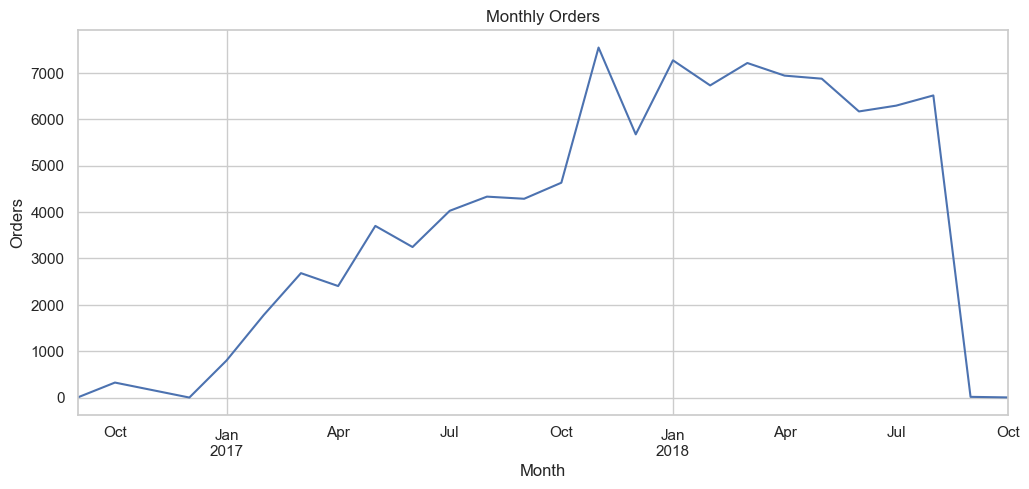

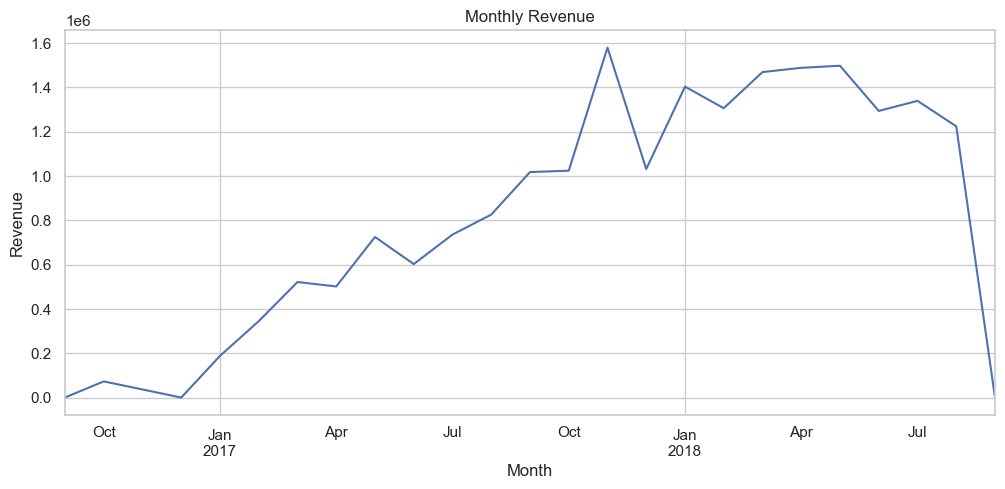

In [17]:
## Trend Analysis
orders['Month'] = orders['order_purchase_timestamp'].dt.to_period('M')
monthly_orders = orders.groupby('Month').size()
monthly_orders.plot(figsize=(12, 5))
plt.title('Monthly Orders')
plt.ylabel('Orders')
plt.show()

merged['Month'] = merged['order_purchase_timestamp'].dt.to_period('M')
monthly_sales = merged.groupby('Month')['payment_value'].sum()
monthly_sales.plot(figsize=(12, 5))
plt.title('Monthly Revenue')
plt.ylabel('Revenue')
plt.show()

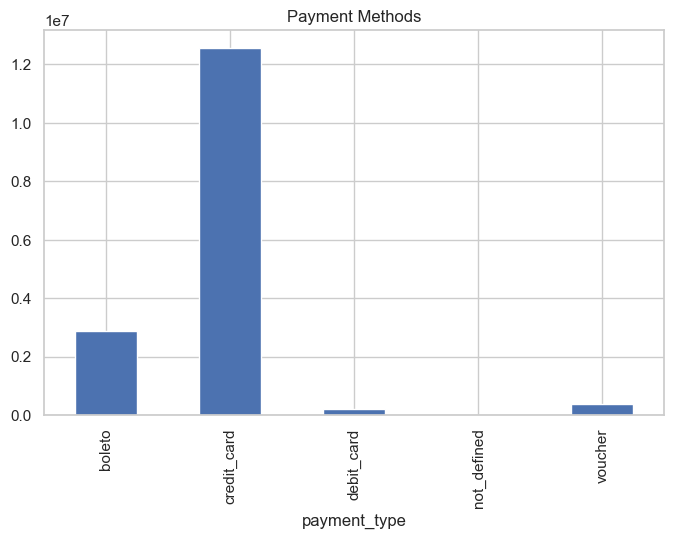

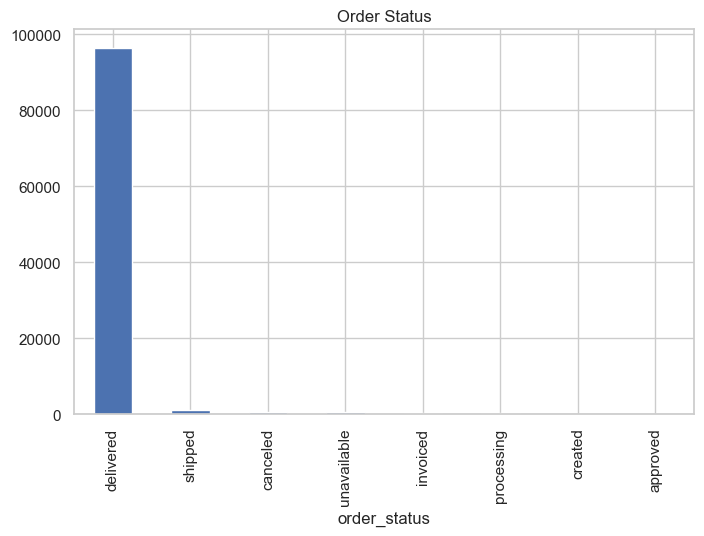

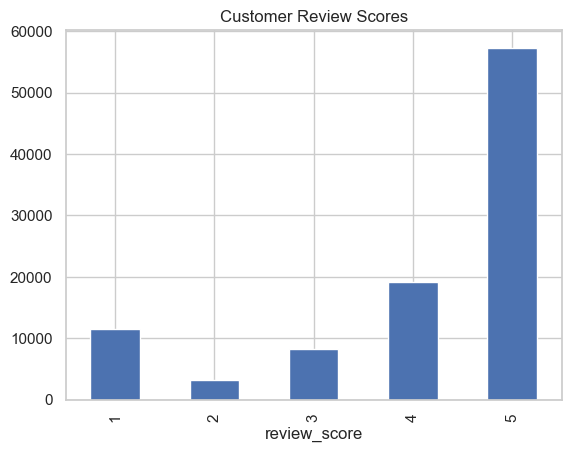

In [18]:
## Payment Analysis
payments.groupby('payment_type')['payment_value'].sum().plot(kind='bar', figsize=(8, 5))
plt.title('Payment Methods')
plt.show()

## Order Status
orders['order_status'].value_counts().plot(kind='bar', figsize=(8, 5))
plt.title('Order Status')
plt.show()

## Review Score Distribution
reviews['review_score'].value_counts().sort_index().plot(kind='bar')
plt.title('Customer Review Scores')
plt.show()

In [24]:
# Cell 1: Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')

In [25]:
# Cell 2: Load datasets
from pathlib import Path

DATA_DIR = Path(r'd:\Data Analytics 1')

def load_csv(name: str) -> pd.DataFrame:
    return pd.read_csv(DATA_DIR / name)

customers = load_csv('olist_customers_dataset.csv')
orders = load_csv('olist_orders_dataset.csv')
items = load_csv('olist_order_items_dataset.csv')
payments = load_csv('olist_order_payments_dataset.csv')
reviews = load_csv('olist_order_reviews_dataset.csv')
products = load_csv('olist_products_dataset.csv')
sellers = load_csv('olist_sellers_dataset.csv')
geolocation = load_csv('olist_geolocation_dataset.csv')
category_map = load_csv('product_category_name_translation.csv')

In [26]:
# Cell 3: Basic inspection
for name, df in {
    'customers': customers,
    'orders': orders,
    'items': items,
    'payments': payments,
    'reviews': reviews,
    'products': products,
    'sellers': sellers,
    'geolocation': geolocation,
    'category_map': category_map,
}.items():
    print(f'{name}: {df.shape}')
    print(df.head(2))
    print()

# Cell 4: Missing values and duplicates
for name, df in {
    'customers': customers,
    'orders': orders,
    'items': items,
    'payments': payments,
    'reviews': reviews,
    'products': products,
    'sellers': sellers,
    'geolocation': geolocation,
}.items():
    print(name)
    print('missing values:\n', df.isnull().sum())
    print('duplicate rows:', df.duplicated().sum())
    print()

customers: (99441, 5)
                        customer_id                customer_unique_id  \
0  06b8999e2fba1a1fbc88172c00ba8bc7  861eff4711a542e4b93843c6dd7febb0   
1  18955e83d337fd6b2def6b18a428ac77  290c77bc529b7ac935b93aa66c333dc3   

   customer_zip_code_prefix          customer_city customer_state  
0                     14409                 franca             SP  
1                      9790  sao bernardo do campo             SP  

orders: (99441, 8)
                           order_id                       customer_id  \
0  e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   
1  53cdb2fc8bc7dce0b6741e2150273451  b0830fb4747a6c6d20dea0b8c802d7ef   

  order_status order_purchase_timestamp    order_approved_at  \
0    delivered      2017-10-02 10:56:33  2017-10-02 11:07:15   
1    delivered      2018-07-24 20:41:37  2018-07-26 03:24:27   

  order_delivered_carrier_date order_delivered_customer_date  \
0          2017-10-04 19:55:00           2017-10-10 21:25

In [27]:
# Cell 5: Cleaning and feature engineering
for col in ['order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']:
    orders[col] = pd.to_datetime(orders[col], errors='coerce')

products['product_category_name'].fillna('Unknown', inplace=True)
products['product_name_lenght'].fillna(products['product_name_lenght'].median(), inplace=True)
reviews['review_comment_message'].fillna('No Review', inplace=True)

orders['delivery_days'] = (orders['order_delivered_customer_date'] - orders['order_purchase_timestamp']).dt.days
orders['delivery_delay'] = (orders['order_delivered_customer_date'] - orders['order_estimated_delivery_date']).dt.days
orders['is_late'] = orders['delivery_delay'] > 0

products = products.merge(category_map, on='product_category_name', how='left')

C:\Users\ASUS\AppData\Local\Temp\ipykernel_10788\2291722383.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  products['product_category_name'].fillna('Unknown', inplace=True)
C:\Users\ASUS\AppData\Local\Temp\ipykernel_10788\2291722383.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a

In [32]:
# Cell 6: Build analysis tables
order_payments = payments.groupby('order_id', as_index=False)['payment_value'].sum()
primary_payment = (
    payments.sort_values(['order_id', 'payment_sequential'])
    .drop_duplicates('order_id')[['order_id', 'payment_type']]
)

order_base = (
    orders.merge(customers[['customer_id', 'customer_state', 'customer_city']], on='customer_id', how='left')
    .merge(order_payments, on='order_id', how='left')
    .merge(reviews[['order_id', 'review_score']], on='order_id', how='left')
    .merge(primary_payment, on='order_id', how='left')
)

order_base['month'] = order_base['order_purchase_timestamp'].dt.to_period('M').astype(str)
order_base['delivery_days'] = (order_base['order_delivered_customer_date'] - order_base['order_purchase_timestamp']).dt.days
order_base['delivery_delay'] = (order_base['order_delivered_customer_date'] - order_base['order_estimated_delivery_date']).dt.days
order_base['is_late'] = order_base['delivery_delay'] > 0

products_en = products.copy()
if 'product_category_name_english' not in products_en.columns:
    if 'product_category_name_y' in products_en.columns and 'product_category_name_x' in products_en.columns:
        products_en = products_en.rename(columns={
            'product_category_name_x': 'product_category_name',
            'product_category_name_y': 'product_category_name_english',
        })
    else:
        products_en = products_en.merge(category_map, on='product_category_name', how='left')
if 'product_category_name_english' not in products_en.columns:
    products_en['product_category_name_english'] = products_en['product_category_name']

item_base = (
    items.merge(orders[['order_id', 'customer_id', 'order_purchase_timestamp', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'order_status']], on='order_id', how='left')
    .merge(customers[['customer_id', 'customer_state', 'customer_city']], on='customer_id', how='left')
    .merge(products_en[['product_id', 'product_category_name', 'product_category_name_english']], on='product_id', how='left')
    .merge(sellers[['seller_id', 'seller_city', 'seller_state']], on='seller_id', how='left')
    .merge(reviews[['order_id', 'review_score']], on='order_id', how='left')
)

item_base['category'] = item_base['product_category_name_english'].fillna(item_base['product_category_name'])
item_base['month'] = item_base['order_purchase_timestamp'].dt.to_period('M').astype(str)
item_base['delivery_days'] = (item_base['order_delivered_customer_date'] - item_base['order_purchase_timestamp']).dt.days
item_base['delivery_delay'] = (item_base['order_delivered_customer_date'] - item_base['order_estimated_delivery_date']).dt.days
item_base['is_late'] = item_base['delivery_delay'] > 0

In [29]:
# Cell 7: Profit analysis
print('Total revenue:', order_base['payment_value'].sum())
print('Average order value:', order_base['payment_value'].mean())

category_revenue = item_base.groupby('category')['price'].sum().sort_values(ascending=False)
seller_revenue = item_base.groupby('seller_id')['price'].sum().sort_values(ascending=False)
state_sales = order_base.groupby('customer_state')['payment_value'].sum().sort_values(ascending=False)
city_sales = order_base.groupby('customer_city')['payment_value'].sum().sort_values(ascending=False)
payment_revenue = order_base.groupby('payment_type')['payment_value'].sum().sort_values(ascending=False)
monthly_revenue = order_base.groupby('month')['payment_value'].sum().sort_index()
product_sales_volume = item_base.groupby('product_id').size().sort_values(ascending=False)

print(category_revenue.head(10))
print(seller_revenue.head(10))
print(state_sales.head(10))
print(city_sales.head(10))
print(payment_revenue)
print(monthly_revenue)
print(product_sales_volume.head(10))

Total revenue: 16081420.74
Average order value: 160.82868198137834
category
health_beauty            1263138.54
watches_gifts            1206075.33
bed_bath_table           1050936.61
sports_leisure            993656.51
computers_accessories     919640.54
furniture_decor           736282.47
cool_stuff                637258.51
housewares                634542.60
auto                      594363.10
garden_tools              486432.45
Name: price, dtype: float64
seller_id
4869f7a5dfa277a7dca6462dcf3b52b2    229472.63
53243585a1d6dc2643021fd1853d8905    222776.05
4a3ca9315b744ce9f8e9374361493884    202999.12
fa1c13f2614d7b5c4749cbc52fecda94    194042.03
7c67e1448b00f6e969d365cea6b010ab    189417.67
7e93a43ef30c4f03f38b393420bc753a    176431.87
da8622b14eb17ae2831f4ac5b9dab84a    162723.37
7a67c85e85bb2ce8582c35f2203ad736    142325.49
1025f0e2d44d7041d6cf58b6550e0bfa    140513.14
955fee9216a65b617aa5c0531780ce60    135241.70
Name: price, dtype: float64
customer_state
SP    6028174.24
RJ    

In [30]:
# Cell 8: Loss analysis
lowest_rated_categories = item_base.groupby('category')['review_score'].mean().sort_values()
late_deliveries_by_seller = (
    item_base[['seller_id', 'order_id']].drop_duplicates()
    .merge(order_base[['order_id', 'is_late']], on='order_id', how='left')
    .groupby('seller_id')['is_late'].sum().sort_values(ascending=False)
)
canceled_orders = (order_base['order_status'] == 'canceled').sum()
state_delivery_time = order_base.groupby('customer_state')['delivery_days'].mean().sort_values(ascending=False)
category_shipping = item_base.groupby('category').agg(
    total_revenue=('price', 'sum'),
    avg_shipping_cost=('freight_value', 'mean'),
    avg_review=('review_score', 'mean'),
    sales_volume=('order_item_id', 'count')
).reset_index()

print(lowest_rated_categories.head(10))
print(late_deliveries_by_seller.head(10))
print('Canceled orders:', canceled_orders)
print(state_delivery_time.head(10))
print(category_shipping.sort_values(['avg_shipping_cost', 'total_revenue'], ascending=[False, True]).head(10))

category
security_and_services                            2.500000
diapers_and_hygiene                              3.256410
portateis_cozinha_e_preparadores_de_alimentos    3.266667
pc_gamer                                         3.333333
office_furniture                                 3.493183
home_comfort_2                                   3.629630
fashion_male_clothing                            3.641221
fixed_telephony                                  3.683206
party_supplies                                   3.767442
fashio_female_clothing                           3.780000
Name: review_score, dtype: float64
seller_id
4a3ca9315b744ce9f8e9374361493884    174
1f50f920176fa81dab994f9023523100    125
4869f7a5dfa277a7dca6462dcf3b52b2    118
6560211a19b47992c3666cc44a7e94c0     97
ea8482cd71df3c1969d7b9473ff13abc     96
7c67e1448b00f6e969d365cea6b010ab     90
cc419e0650a3c5ba77189a1882b7556a     89
da8622b14eb17ae2831f4ac5b9dab84a     88
8b321bb669392f5163d04c59e235e066     81
955fee

In [31]:
# Cell 9: Customer analysis
state_customer_count = customers['customer_state'].value_counts()
city_revenue = order_base.groupby('customer_city')['payment_value'].sum().sort_values(ascending=False)
avg_review_by_category = item_base.groupby('category')['review_score'].mean().sort_values(ascending=False)
payment_preference = primary_payment['payment_type'].value_counts()

print(state_customer_count.head(10))
print(city_revenue.head(10))
print(avg_review_by_category.head(10))
print(payment_preference)

# Cell 10: Delivery performance
average_delivery_time = order_base['delivery_days'].mean()
late_orders = order_base['is_late'].sum()
fastest_sellers = item_base[['seller_id', 'order_id']].drop_duplicates().merge(
    order_base[['order_id', 'delivery_days']], on='order_id', how='left'
).groupby('seller_id')['delivery_days'].mean().sort_values()
delay_regions = order_base.groupby('customer_state')['delivery_delay'].mean().sort_values(ascending=False)
delivery_review_corr = order_base[['delivery_days', 'review_score']].corr()

print('Average delivery time:', average_delivery_time)
print('Late orders:', late_orders)
print(fastest_sellers.head(10))
print(delay_regions.head(10))
print(delivery_review_corr)

# Cell 11: Trend analysis
monthly_orders = order_base.groupby('month').size()
monthly_rating = order_base.groupby('month')['review_score'].mean()
category_growth = item_base.groupby(['month', 'category'])['price'].sum().reset_index()
category_growth_pivot = category_growth.pivot(index='month', columns='category', values='price').fillna(0)
category_slopes = pd.Series({
    cat: np.polyfit(np.arange(len(category_growth_pivot)), category_growth_pivot[cat].values, 1)[0]
    for cat in category_growth_pivot.columns
}).sort_values(ascending=False)

print(monthly_orders)
print(monthly_rating)
print(category_slopes.head(10))

customer_state
SP    41746
RJ    12852
MG    11635
RS     5466
PR     5045
SC     3637
BA     3380
DF     2140
ES     2033
GO     2020
Name: count, dtype: int64
customer_city
sao paulo         2216168.84
rio de janeiro    1167989.35
belo horizonte     423987.81
brasilia           356780.03
curitiba           248040.80
porto alegre       226256.48
salvador           219039.69
campinas           218124.14
guarulhos          165414.43
niteroi            140681.08
Name: payment_value, dtype: float64
category
cds_dvds_musicals                        4.642857
fashion_childrens_clothes                4.500000
books_general_interest                   4.446266
costruction_tools_tools                  4.444444
flowers                                  4.419355
books_imported                           4.400000
books_technical                          4.368421
food_drink                               4.315412
luggage_accessories                      4.315257
small_appliances_home_oven_and_coffee   

KeyError: 'month'

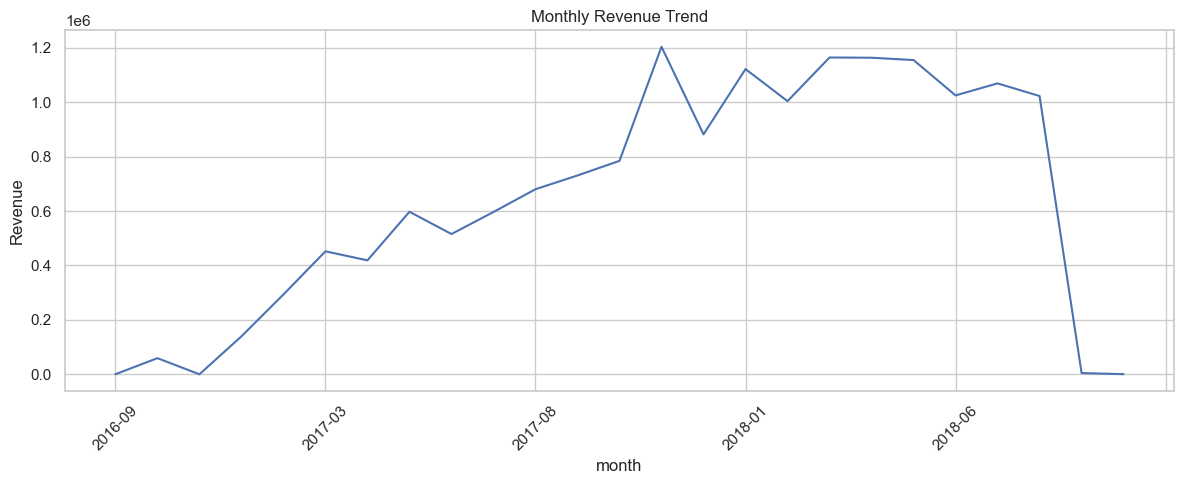

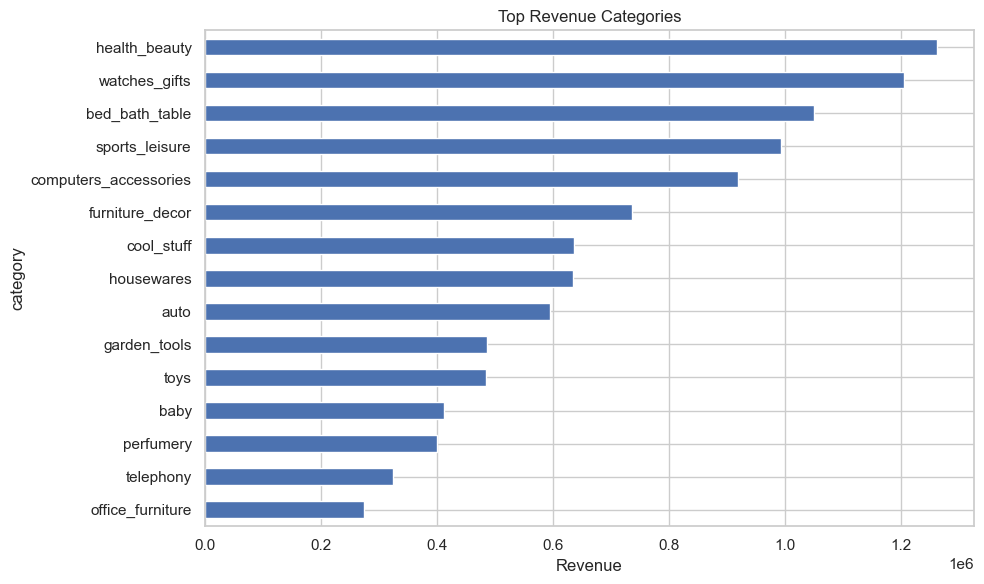

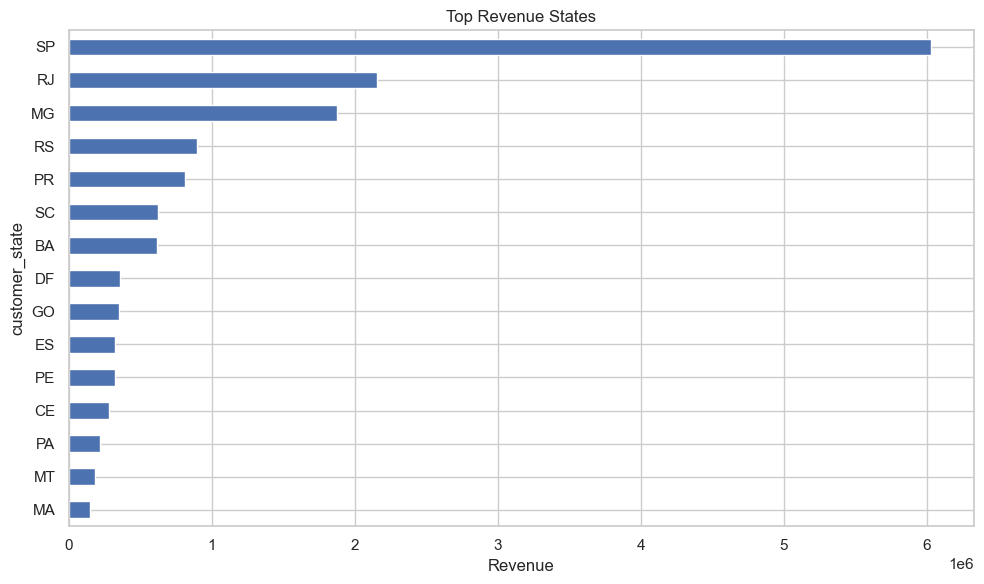

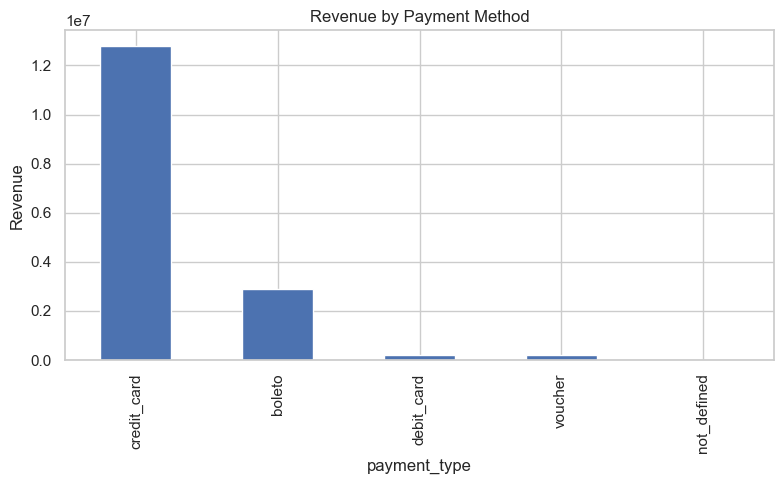

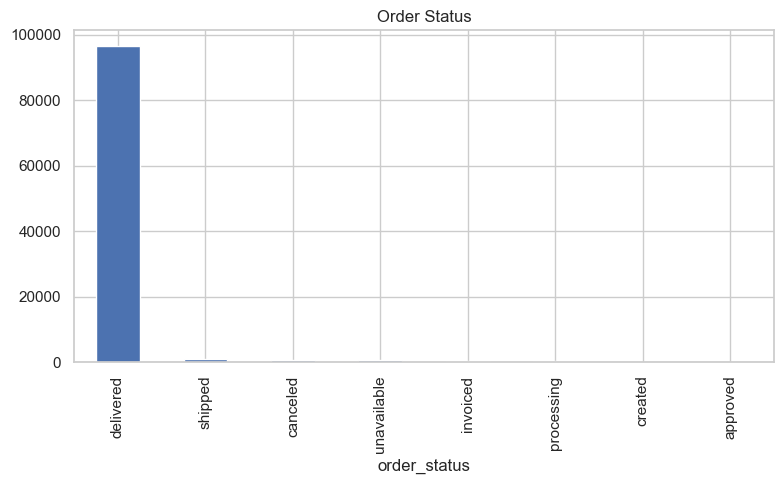

In [33]:
# Cell 12: Visualizations
if 'order_base' not in globals() or 'item_base' not in globals():
    order_payments = payments.groupby('order_id', as_index=False)['payment_value'].sum()
    primary_payment = (
        payments.sort_values(['order_id', 'payment_sequential'])
        .drop_duplicates('order_id')[['order_id', 'payment_type']]
    )
    products_en = products.copy()
    if 'product_category_name_english' not in products_en.columns:
        if 'product_category_name_y' in products_en.columns and 'product_category_name_x' in products_en.columns:
            products_en = products_en.rename(columns={
                'product_category_name_x': 'product_category_name',
                'product_category_name_y': 'product_category_name_english',
            })
        else:
            products_en = products_en.merge(category_map, on='product_category_name', how='left')
    if 'product_category_name_english' not in products_en.columns:
        products_en['product_category_name_english'] = products_en['product_category_name']

    order_base = (
        orders.merge(customers[['customer_id', 'customer_state', 'customer_city']], on='customer_id', how='left')
        .merge(order_payments, on='order_id', how='left')
        .merge(reviews[['order_id', 'review_score']], on='order_id', how='left')
        .merge(primary_payment, on='order_id', how='left')
    )
    item_base = (
        items.merge(orders[['order_id', 'customer_id', 'order_purchase_timestamp', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'order_status']], on='order_id', how='left')
        .merge(customers[['customer_id', 'customer_state', 'customer_city']], on='customer_id', how='left')
        .merge(products_en[['product_id', 'product_category_name', 'product_category_name_english']], on='product_id', how='left')
        .merge(sellers[['seller_id', 'seller_city', 'seller_state']], on='seller_id', how='left')
        .merge(reviews[['order_id', 'review_score']], on='order_id', how='left')
    )
    order_base['month'] = order_base['order_purchase_timestamp'].dt.to_period('M').astype(str)
    item_base['month'] = item_base['order_purchase_timestamp'].dt.to_period('M').astype(str)
    item_base['category'] = item_base['product_category_name_english'].fillna(item_base['product_category_name'])

if 'month' not in order_base.columns:
    order_base['month'] = order_base['order_purchase_timestamp'].dt.to_period('M').astype(str)
if 'month' not in item_base.columns:
    item_base['month'] = item_base['order_purchase_timestamp'].dt.to_period('M').astype(str)
if 'category' not in item_base.columns:
    if 'product_category_name_english' in item_base.columns:
        item_base['category'] = item_base['product_category_name_english'].fillna(item_base['product_category_name'])
    else:
        item_base['category'] = item_base['product_category_name']

monthly_revenue = order_base.groupby('month')['payment_value'].sum().sort_index()
category_revenue = item_base.groupby('category')['price'].sum().sort_values(ascending=False)
state_sales = order_base.groupby('customer_state')['payment_value'].sum().sort_values(ascending=False)
payment_revenue = order_base.groupby('payment_type')['payment_value'].sum().sort_values(ascending=False)

plt.figure(figsize=(12, 5))
monthly_revenue.plot()
plt.title('Monthly Revenue Trend')
plt.ylabel('Revenue')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
category_revenue.head(15).sort_values().plot(kind='barh')
plt.title('Top Revenue Categories')
plt.xlabel('Revenue')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
state_sales.head(15).sort_values().plot(kind='barh')
plt.title('Top Revenue States')
plt.xlabel('Revenue')
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
payment_revenue.plot(kind='bar')
plt.title('Revenue by Payment Method')
plt.ylabel('Revenue')
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
orders['order_status'].value_counts().plot(kind='bar')
plt.title('Order Status')
plt.tight_layout()
plt.show()

# Cell 13: Export cleaned data
order_base.to_csv('cleaned_olist_order_level.csv', index=False)
item_base.to_csv('cleaned_olist_item_level.csv', index=False)

In [34]:
# Tableau-ready full export
# One row per order-item with order, customer, product, seller, payment, review, and delivery fields.
if 'order_base' not in globals() or 'item_base' not in globals():
    order_payments = payments.groupby('order_id', as_index=False)['payment_value'].sum()
    primary_payment = (
        payments.sort_values(['order_id', 'payment_sequential'])
        .drop_duplicates('order_id')[['order_id', 'payment_type']]
    )
    products_en = products.copy()
    if 'product_category_name_english' not in products_en.columns:
        if 'product_category_name_y' in products_en.columns and 'product_category_name_x' in products_en.columns:
            products_en = products_en.rename(columns={
                'product_category_name_x': 'product_category_name',
                'product_category_name_y': 'product_category_name_english',
            })
        else:
            products_en = products_en.merge(category_map, on='product_category_name', how='left')
    if 'product_category_name_english' not in products_en.columns:
        products_en['product_category_name_english'] = products_en['product_category_name']

    order_base = (
        orders.merge(customers[['customer_id', 'customer_state', 'customer_city']], on='customer_id', how='left')
        .merge(order_payments, on='order_id', how='left')
        .merge(reviews[['order_id', 'review_score']], on='order_id', how='left')
        .merge(primary_payment, on='order_id', how='left')
    )
    item_base = (
        items.merge(orders[['order_id', 'customer_id', 'order_purchase_timestamp', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'order_status']], on='order_id', how='left')
        .merge(customers[['customer_id', 'customer_state', 'customer_city']], on='customer_id', how='left')
        .merge(products_en[['product_id', 'product_category_name', 'product_category_name_english']], on='product_id', how='left')
        .merge(sellers[['seller_id', 'seller_city', 'seller_state']], on='seller_id', how='left')
        .merge(reviews[['order_id', 'review_score']], on='order_id', how='left')
    )
    order_base['month'] = order_base['order_purchase_timestamp'].dt.to_period('M').astype(str)
    item_base['month'] = item_base['order_purchase_timestamp'].dt.to_period('M').astype(str)
    item_base['category'] = item_base['product_category_name_english'].fillna(item_base['product_category_name'])

# Aggregate payment data to the order level before joining, so Tableau totals are not duplicated across multiple payment rows.
payment_summary = payments.groupby('order_id', as_index=False).agg(
    payment_value_total=('payment_value', 'sum'),
    payment_installments_avg=('payment_installments', 'mean')
)
primary_payment = (
    payments.sort_values(['order_id', 'payment_sequential'])
    .drop_duplicates('order_id')[['order_id', 'payment_type']]
)

products_en = products.copy()
if 'product_category_name_english' not in products_en.columns:
    if 'product_category_name_y' in products_en.columns and 'product_category_name_x' in products_en.columns:
        products_en = products_en.rename(columns={
            'product_category_name_x': 'product_category_name',
            'product_category_name_y': 'product_category_name_english',
        })
    else:
        products_en = products_en.merge(category_map, on='product_category_name', how='left')
if 'product_category_name_english' not in products_en.columns:
    products_en['product_category_name_english'] = products_en['product_category_name']

# Full Tableau dataset: one row per order-item, enriched with all useful fields.
tableau_full = (
    items
    .merge(orders, on='order_id', how='left')
    .merge(customers, on='customer_id', how='left')
    .merge(products_en, on='product_id', how='left')
    .merge(sellers, on='seller_id', how='left')
    .merge(payment_summary, on='order_id', how='left')
    .merge(primary_payment, on='order_id', how='left')
    .merge(reviews[['order_id', 'review_score', 'review_comment_title', 'review_comment_message']], on='order_id', how='left')
)

tableau_full['order_purchase_timestamp'] = pd.to_datetime(tableau_full['order_purchase_timestamp'], errors='coerce')
tableau_full['order_delivered_customer_date'] = pd.to_datetime(tableau_full['order_delivered_customer_date'], errors='coerce')
tableau_full['order_estimated_delivery_date'] = pd.to_datetime(tableau_full['order_estimated_delivery_date'], errors='coerce')
tableau_full['month'] = tableau_full['order_purchase_timestamp'].dt.to_period('M').astype(str)
tableau_full['delivery_days'] = (tableau_full['order_delivered_customer_date'] - tableau_full['order_purchase_timestamp']).dt.days
tableau_full['delivery_delay'] = (tableau_full['order_delivered_customer_date'] - tableau_full['order_estimated_delivery_date']).dt.days
tableau_full['is_late'] = tableau_full['delivery_delay'] > 0

tableau_full.to_csv(DATA_DIR / 'olist_tableau_full_dataset.csv', index=False)
print('Saved:', DATA_DIR / 'olist_tableau_full_dataset.csv')
print('Rows, columns:', tableau_full.shape)
print(tableau_full.head())

Saved: d:\Data Analytics 1\olist_tableau_full_dataset.csv
Rows, columns: (113314, 40)
                           order_id  order_item_id  \
0  00010242fe8c5a6d1ba2dd792cb16214              1   
1  00018f77f2f0320c557190d7a144bdd3              1   
2  000229ec398224ef6ca0657da4fc703e              1   
3  00024acbcdf0a6daa1e931b038114c75              1   
4  00042b26cf59d7ce69dfabb4e55b4fd9              1   

                         product_id                         seller_id  \
0  4244733e06e7ecb4970a6e2683c13e61  48436dade18ac8b2bce089ec2a041202   
1  e5f2d52b802189ee658865ca93d83a8f  dd7ddc04e1b6c2c614352b383efe2d36   
2  c777355d18b72b67abbeef9df44fd0fd  5b51032eddd242adc84c38acab88f23d   
3  7634da152a4610f1595efa32f14722fc  9d7a1d34a5052409006425275ba1c2b4   
4  ac6c3623068f30de03045865e4e10089  df560393f3a51e74553ab94004ba5c87   

   shipping_limit_date   price  freight_value  \
0  2017-09-19 09:45:35   58.90          13.29   
1  2017-05-03 11:05:13  239.90          19.93   
2  